# Customer Analytics — Level 5: RFM Segmentation

After identifying customer value through Customer Lifetime Value (CLV) analysis, the next step is to understand how customers differ in their purchasing behavior.

Recency, Frequency, and Monetary (RFM) Analysis is one of the most widely used customer segmentation frameworks in retail and e-commerce because it is both simple and highly actionable.

The framework evaluates customers across three dimensions:

- **Recency (R):** How recently a customer made a purchase.
- **Frequency (F):** How often a customer purchases.
- **Monetary (M):** How much revenue a customer generates.

By combining these dimensions, customers can be grouped into meaningful segments that support targeted marketing, retention strategies, and customer relationship management initiatives.

Data source: `online_retail_clean.csv` from the Level 1 data preparation workflow.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

np.random.seed(42)

sns.set_theme(style="whitegrid", palette="deep")
sns.set_context("talk")
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns', None)
df = pd.read_csv("data/raw/online_retail_clean.csv", parse_dates=["InvoiceDate"])
print(f"Total customers: {df['CustomerID'].nunique():,}")

Total customers: 4,338


## 1. Calculating Raw RFM Metrics

The first step is to calculate the three fundamental RFM variables for every customer.

To measure Recency, we define a snapshot date representing the reference point for the analysis. This date is set one day after the latest transaction in the dataset, allowing us to calculate the number of days since each customer's most recent purchase.

For every customer, we then compute:

- Recency: Days since last purchase
- Frequency: Number of orders placed
- Monetary: Total revenue generated

These metrics form the foundation for customer scoring and segmentation.

In [2]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Snapshot date: {snapshot_date.date()}")

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("Revenue", "sum")
).reset_index()

print(rfm.describe().round(1))
rfm.head()

Snapshot date: 2011-12-10
       CustomerID  Recency  Frequency   Monetary
count    4,338.00 4,338.00   4,338.00   4,338.00
mean    15,300.40    92.50       4.30   2,054.30
std      1,721.80   100.00       7.70   8,989.20
min     12,346.00     1.00       1.00       3.80
25%     13,813.20    18.00       1.00     307.40
50%     15,299.50    51.00       2.00     674.50
75%     16,778.80   142.00       5.00   1,661.70
max     18,287.00   374.00     209.00 280,206.00


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,"77,183.60"
1,12347,2,7,"4,310.00"
2,12348,75,4,"1,797.24"
3,12349,19,1,"1,757.55"
4,12350,310,1,334.40


### Exploring RFM Metric Distributions

Before assigning scores, it is important to understand the distribution of Recency, Frequency, and Monetary values across the customer base.

These distributions reveal behavioral differences between customers and help explain how the scoring framework separates high-value customers from lower-engagement segments.

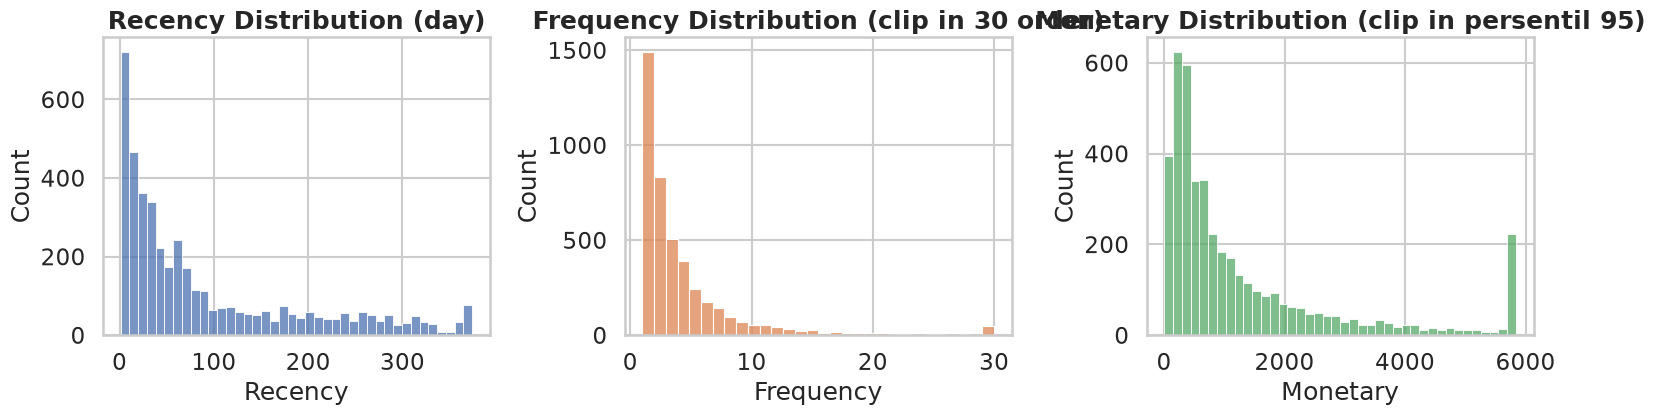

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(rfm["Recency"], bins=40, color="#4C72B0", ax=axes[0])
axes[0].set_title("Recency Distribution (day)")

sns.histplot(rfm["Frequency"].clip(upper=30), bins=30, color="#DD8452", ax=axes[1])
axes[1].set_title("Frequency Distribution (clip in 30 order)")

sns.histplot(rfm["Monetary"].clip(upper=rfm["Monetary"].quantile(0.95)), bins=40, color="#55A868", ax=axes[2])
axes[2].set_title("Monetary Distribution (clip in persentil 95)")

plt.tight_layout()
plt.savefig("pictures/level5_rfm_distributions.png", dpi=120, bbox_inches='tight')
plt.show()

## 2. RFM Scoring

Raw RFM values are transformed into standardized scores ranging from 1 to 5 using quintile-based ranking.

Customers with stronger purchasing behavior receive higher scores:

- Lower Recency values receive higher scores because recent purchases indicate stronger engagement.
- Higher Frequency values receive higher scores because frequent customers are generally more valuable.
- Higher Monetary values receive higher scores because they contribute more revenue.

This scoring process creates a consistent framework for comparing customers across multiple behavioral dimensions.

In [4]:
rfm["R_Score"] = pd.qcut(rfm["Recency"], 5, labels=[5,4,3,2,1]).astype(int)
rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)
rfm["M_Score"] = pd.qcut(rfm["Monetary"].rank(method="first"), 5, labels=[1,2,3,4,5]).astype(int)

rfm["RFM_Score"] = rfm["R_Score"].astype(str) + rfm["F_Score"].astype(str) + rfm["M_Score"].astype(str)
rfm[["CustomerID","Recency","Frequency","Monetary","R_Score","F_Score","M_Score","RFM_Score"]].head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,"77,183.60",1,1,5,115
1,12347,2,7,"4,310.00",5,5,5,555
2,12348,75,4,"1,797.24",2,4,4,244
3,12349,19,1,"1,757.55",4,1,4,414
4,12350,310,1,334.40,1,1,2,112
5,12352,36,8,"2,506.04",3,5,5,355
6,12353,204,1,89.00,1,1,1,111
7,12354,232,1,"1,079.40",1,1,4,114
8,12355,214,1,459.40,1,1,2,112
9,12356,23,3,"2,811.43",4,3,5,435


## 3. Customer Segmentation

Once RFM scores are calculated, customers are grouped into business-oriented segments based on their purchasing behavior.

Each segment represents a distinct customer profile with different levels of engagement, loyalty, and revenue potential. These groups allow businesses to move beyond customer averages and design targeted strategies for retention, reactivation, acquisition, and growth.

The segmentation rules below classify customers into categories such as Champions, Loyal Customers, Potential Loyalists, At Risk Customers, and Lost Customers.

In [5]:
def segment(row):
    R, F, M = row["R_Score"], row["F_Score"], row["M_Score"]
    if R >= 4 and F >= 4 and M >= 4:
        return "Champions"
    elif F >= 4 and R >= 3:
        return "Loyal Customers"
    elif R >= 4 and 2 <= F <= 3:
        return "Potential Loyalists"
    elif R >= 4 and F == 1:
        return "New Customers"
    elif 2 <= R <= 3 and F >= 2:
        return "At Risk"
    elif R == 1 and F >= 3:
        return "Cant Lose Them"
    elif R <= 2 and F <= 2:
        return "Lost Customers"
    else:
        return "Others"

rfm["Segment"] = rfm.apply(segment, axis=1)

seg_count = rfm["Segment"].value_counts()
seg_pct = (seg_count / len(rfm) * 100).round(1)
pd.DataFrame({"Customers": seg_count, "Pct%": seg_pct}).sort_values("Customers", ascending=False)

,Customers,Pct%
Segment,,
At Risk,1017,23.40
Champions,962,22.20
Lost Customers,863,19.90
Loyal Customers,498,11.50
Potential Loyalists,492,11.30
Cant Lose Them,201,4.60
Others,164,3.80
New Customers,141,3.30


### Segment Distribution Across the Customer Base

The chart below illustrates how customers are distributed across the RFM segments.

Understanding segment size is important because it highlights where the majority of customers currently sit within the customer lifecycle and identifies opportunities for retention or reactivation initiatives.

/tmp/ipykernel_16026/2597128786.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, y="Segment", order=seg_order, palette="viridis", ax=ax)


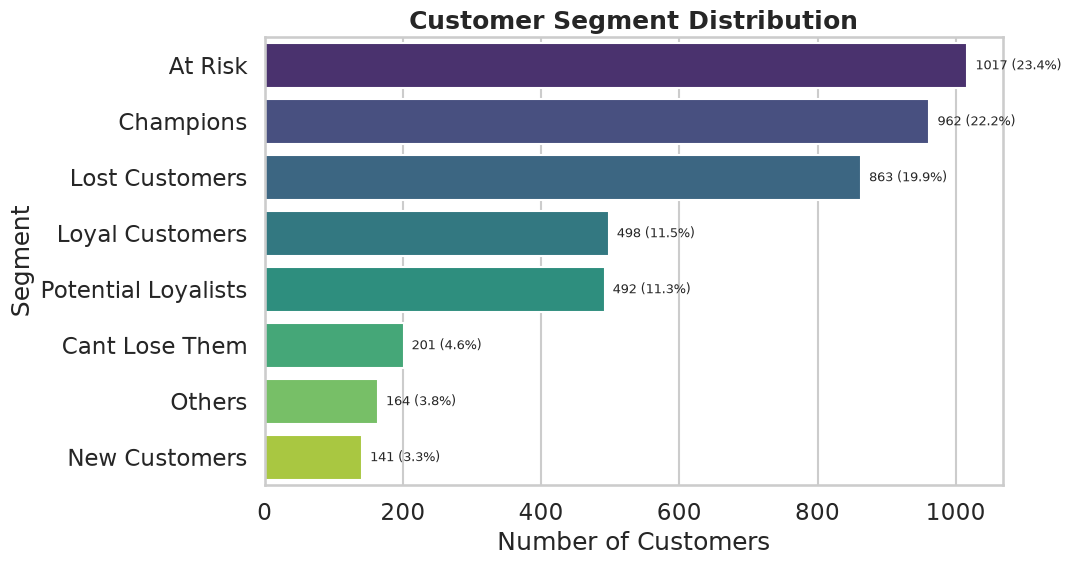

In [6]:
seg_order = rfm["Segment"].value_counts().index

fig, ax = plt.subplots(figsize=(11, 6))
sns.countplot(data=rfm, y="Segment", order=seg_order, palette="viridis", ax=ax)
ax.set_title("Customer Segment Distribution")
ax.set_xlabel("Number of Customers")
for i, seg in enumerate(seg_order):
    count = (rfm["Segment"]==seg).sum()
    pct = count/len(rfm)*100
    ax.text(count, i, f"  {count} ({pct:.1f}%)", va='center', fontsize=9)
plt.tight_layout()
plt.savefig("pictures/level5_segment_distribution.png", dpi=120, bbox_inches='tight')
plt.show()

## 4. Revenue and Profit Contribution by Segment

Customer segments differ not only in behavior but also in economic value.

In this section, we evaluate how much revenue and profit each segment contributes to overall business performance. This analysis helps identify which customer groups generate the greatest value and which segments may require additional attention to improve profitability.

In [7]:
profit_per_cust = df.groupby("CustomerID")["Profit"].sum().reset_index()
rfm = rfm.merge(profit_per_cust, on="CustomerID")

seg_summary = rfm.groupby("Segment").agg(
    Customers=("CustomerID","count"),
    TotalRevenue=("Monetary","sum"),
    TotalProfit=("Profit","sum"),
    AvgRecency=("Recency","mean"),
    AvgFrequency=("Frequency","mean"),
    AvgMonetary=("Monetary","mean")
).sort_values("TotalRevenue", ascending=False)

seg_summary["RevenuePct%"] = (seg_summary["TotalRevenue"]/seg_summary["TotalRevenue"].sum()*100).round(1)
seg_summary["CustomerPct%"] = (seg_summary["Customers"]/seg_summary["Customers"].sum()*100).round(1)
seg_summary.round(2)

,Customers,TotalRevenue,TotalProfit,AvgRecency,AvgFrequency,AvgMonetary,RevenuePct%,CustomerPct%
Segment,,,,,,,,
Champions,962,"5,809,341.07","2,464,176.91",12.86,11.08,"6,038.82",65.20,22.20
At Risk,1017,"926,292.21","395,021.11",92.73,2.49,910.81,10.40,23.40
Loyal Customers,498,"894,239.80","379,718.32",38.20,5.10,"1,795.66",10.00,11.50
Potential Loyalists,492,"509,173.49","202,718.80",17.12,2.01,"1,034.91",5.70,11.30
Lost Customers,863,"409,084.61","176,084.41",241.18,1.05,474.03,4.60,19.90
Cant Lose Them,201,"242,865.34","100,730.42",237.31,3.00,"1,208.29",2.70,4.60
Others,164,"68,926.66","29,587.10",53.91,1.00,420.28,0.80,3.80
New Customers,141,"51,484.72","21,808.29",18.50,1.00,365.14,0.60,3.30


### Comparing Economic Contribution Across Segments

The following visualizations compare revenue and profit generated by each customer segment.

This perspective allows us to distinguish between segments that are large in size and segments that are truly valuable from a business standpoint.

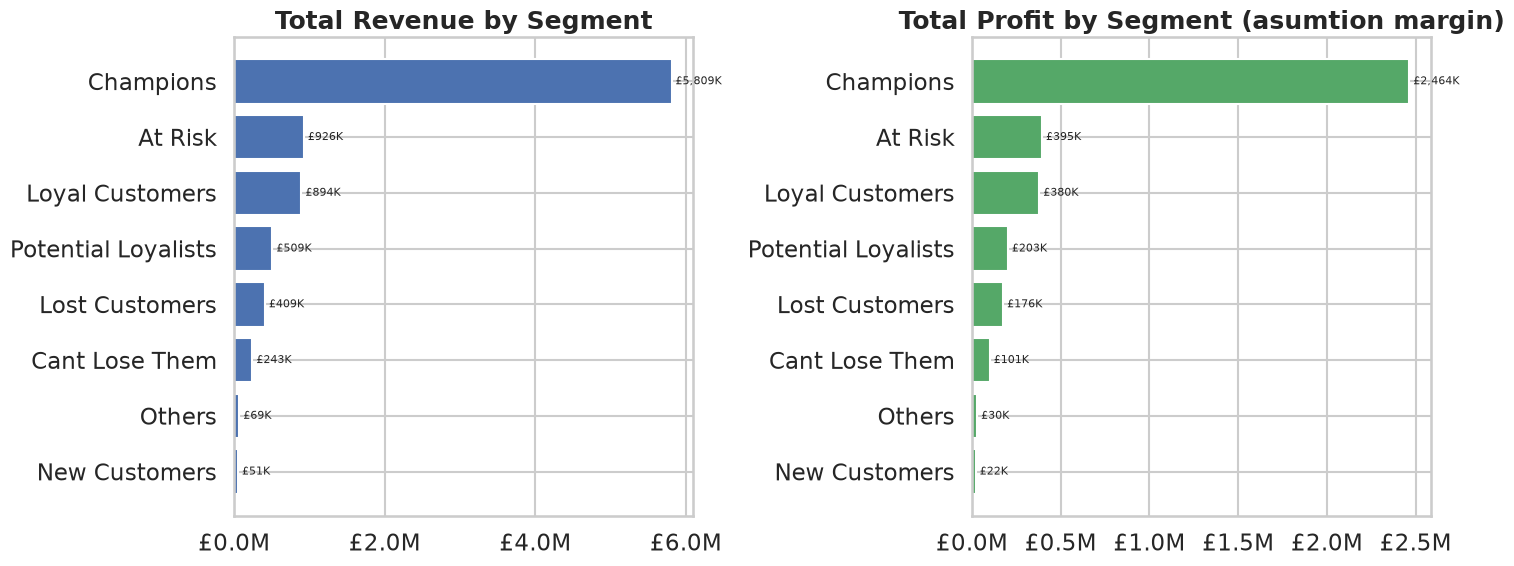

Champions: 22.2% customer -> 65.2% revenue


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

seg_summary_sorted = seg_summary.sort_values("TotalRevenue")
axes[0].barh(seg_summary_sorted.index, seg_summary_sorted["TotalRevenue"], color="#4C72B0")
axes[0].set_title("Total Revenue by Segment")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1e6:.1f}M"))
for i, v in enumerate(seg_summary_sorted["TotalRevenue"]):
    axes[0].text(v, i, f" £{v/1000:,.0f}K", va='center', fontsize=8)

seg_summary_sorted_p = seg_summary.sort_values("TotalProfit")
axes[1].barh(seg_summary_sorted_p.index, seg_summary_sorted_p["TotalProfit"], color="#55A868")
axes[1].set_title("Total Profit by Segment (asumtion margin)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x/1e6:.1f}M"))
for i, v in enumerate(seg_summary_sorted_p["TotalProfit"]):
    axes[1].text(v, i, f" £{v/1000:,.0f}K", va='center', fontsize=8)

plt.tight_layout()
plt.savefig("pictures/level5_revenue_profit_by_segment.png", dpi=120, bbox_inches='tight')
plt.show()

champions_rev_pct = seg_summary.loc["Champions","RevenuePct%"]
champions_cust_pct = seg_summary.loc["Champions","CustomerPct%"]
print(f"Champions: {champions_cust_pct}% customer -> {champions_rev_pct}% revenue")

## 5. RFM Heatmap Analysis

While customer segments provide a simplified business view, examining the underlying score combinations offers deeper insight into customer behavior.

The heatmap visualizes the distribution of customers across Recency and Frequency score combinations, making it easier to identify clusters of highly engaged customers, declining customers, and underserved opportunities.

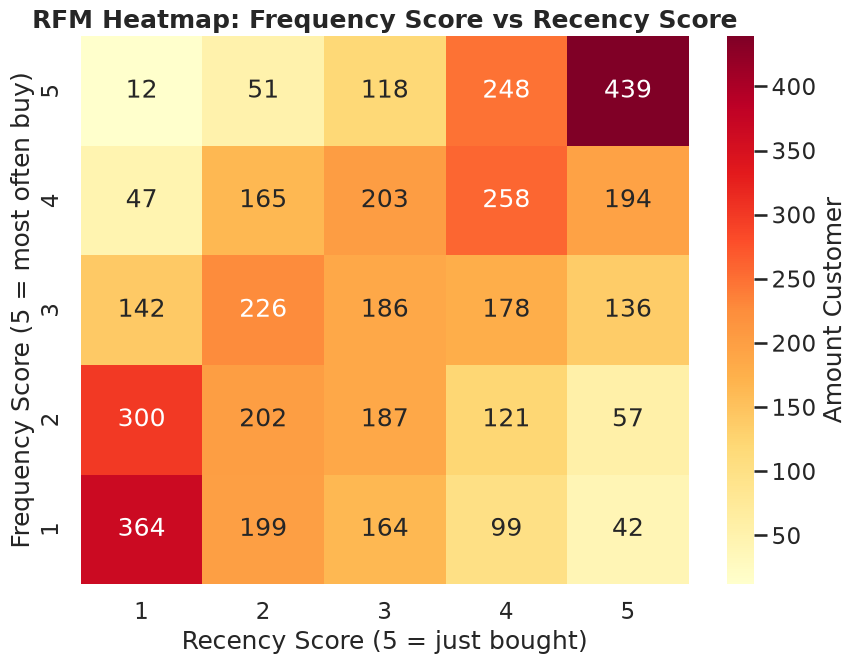

In [10]:
rfm_heatmap_data = rfm.pivot_table(index="F_Score", columns="R_Score", values="CustomerID", aggfunc="count", fill_value=0)
rfm_heatmap_data = rfm_heatmap_data.sort_index(ascending=False)  # High F above

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(rfm_heatmap_data, annot=True, fmt="d", cmap="YlOrRd", ax=ax, cbar_kws={'label': 'Amount Customer'})
ax.set_title("RFM Heatmap: Frequency Score vs Recency Score")
ax.set_xlabel("Recency Score (5 = just bought)")
ax.set_ylabel("Frequency Score (5 = most often buy)")
plt.tight_layout()
plt.savefig("pictures/level5_rfm_heatmap.png", dpi=120, bbox_inches='tight')
plt.show()

In [11]:
rfm.to_csv("data/processed/rfm_segments.csv", index=False)
print("RFM table with saved segments to data/processed/rfm_segments.csv")

RFM table with saved segments to data/processed/rfm_segments.csv


## 6. Executive Summary

RFM segmentation reveals substantial differences in customer behavior across the customer base.

The analysis identifies a group of highly engaged customers who purchase frequently, buy recently, and generate significant revenue. These customers represent the business's strongest retention assets and should be prioritized for loyalty and relationship-building initiatives.

At the same time, several segments exhibit signs of declining engagement. Customers with lower recency scores may represent valuable reactivation opportunities, particularly if they previously demonstrated strong purchasing behavior.

The segmentation framework transforms customer data into actionable business groups, enabling more targeted marketing strategies than broad customer-level averages.

Combined with the Customer Lifetime Value analysis from Level 4, RFM segmentation provides a practical foundation for customer prioritization, retention planning, and future recommendation systems.

### Next Steps

- **Level 6:** Customer Behavior Analysis (purchase timing, order intervals, basket characteristics)
- **Level 7:** Business Recommendation Engine (segment-specific business actions and strategic recommendations)